In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Project :
# SemanticEdge-Trans: Low-Bandwidth Kidney CT Transmission using Semantic Reconstruction

## Problem Statement
Kidney diseases require timely diagnosis, but transmitting full CT/MRI scans in rural or low-bandwidth settings is challenging. Traditional compression methods often lose critical medical details, making remote diagnosis unreliable.

## Project Goal
This project proposes a semantic-aware pipeline that:
1. Extracts important kidney structures (segmentation + edges).
2. Compresses and transmits these semantic maps over noisy channels.
3. Reconstructs high-quality kidney images using conditional diffusion models.

## Solution Pipeline
1. **Dataset Loading & Preprocessing**  
   - Use KiTS21 dataset (kidney CT scans).  
   - Normalize, resize, and prepare slices.  

2. **Semantic Extraction**  
   - Apply segmentation (U-Net / TotalSegmentator).  
   - Extract kidney masks + edge maps.  

3. **Compression & Transmission Simulation**  
   - Downsample semantic maps.  
   - Simulate noisy channels (AWGN, bit errors).  

4. **Channel-Aware Denoising**  
   - Train U-Net denoiser with channel state info.  

5. **Diffusion-Based Reconstruction**  
   - Use conditional diffusion models to reconstruct CT slices.  

6. **Evaluation**  
   - Dice Score, IoU for segmentation.  
   - FID / LPIPS for image similarity.  

## Expected Outcome
- Efficient transmission of kidney images in low-bandwidth scenarios.  
- Robust reconstruction preserving fine kidney structures.  
- Demonstration of telehealth potential for rural healthcare.  


# SemanticEdge-Trans: Kidney CT Reconstruction
## Step 2: Install Required Libraries

In this step, we install all the essential Python libraries needed for SemanticEdge-Trans:

- **torch** & **torchvision**: Core PyTorch libraries for building and training neural networks.
- **opencv-python**: For image processing and edge detection.
- **kaggle**: To directly download datasets from Kaggle into Colab.

After running this, our environment will be ready for data loading and preprocessing.


In [ ]:
# Install PyTorch, torchvision, OpenCV, and Kaggle API
!pip install torch torchvision torchaudio --quiet
!pip install opencv-python --quiet
!pip install kaggle --quiet

# Check versions to confirm installation
import torch
import torchvision
import cv2
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("OpenCV version:", cv2.__version__)

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
OpenCV version: 4.13.0


## Step 3: Upload & Organize Dataset
 we will:

1. Upload the ZIP file to Google Drive (e.g., in `/MyDrive/KidneyDataset/`).
2. Unzip it in Colab to a working folder (`/content/dataset`) for easy access.
3. Verify the folder structure (`train`, `val`, `test`) so our DataLoader can find the images.

Train images: 2000, Validation images: 400, Test images: 400


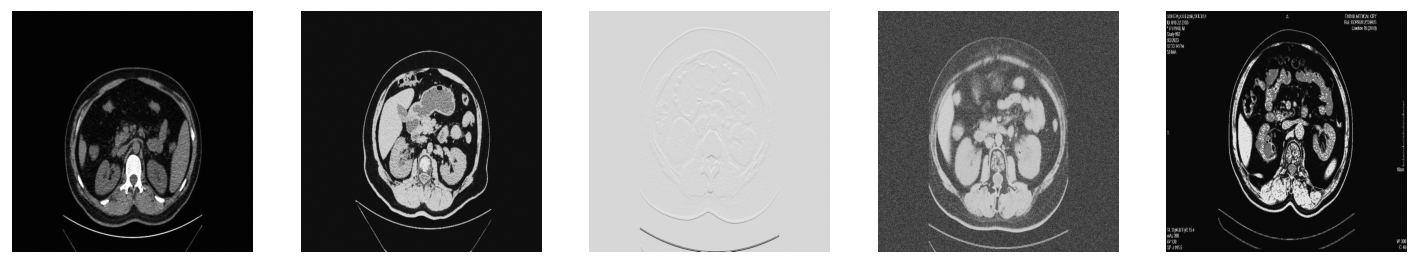

In [ ]:
import os
import random
from glob import glob
import matplotlib.pyplot as plt
import cv2

# Paths
train_path = "/content/drive/MyDrive/Colab Notebooks/Kidney_Semantic_Project/dataset/train"
validation_path = "/content/drive/MyDrive/Colab Notebooks/Kidney_Semantic_Project/dataset/validation"
test_path = "/content/drive/MyDrive/Colab Notebooks/Kidney_Semantic_Project/dataset/test"

# Function to get all images recursively from a folder
def get_images(folder):
    exts = ["*.jpg", "*.png", "*.jpeg"]
    images = []
    for ext in exts:
        images.extend(glob(os.path.join(folder, "**", ext), recursive=True))
    return images

# Get all images
train_images = get_images(train_path)
validation_images = get_images(validation_path)
test_images = get_images(test_path)

print(f"Train images: {len(train_images)}, Validation images: {len(validation_images)}, Test images: {len(test_images)}")

# Display 5 random images from train folder
sample_images = random.sample(train_images, min(5, len(train_images)))

plt.figure(figsize=(15,5))
for i, img_file in enumerate(sample_images):
    img = cv2.imread(img_file, cv2.IMREAD_GRAYSCALE)
    plt.subplot(1, len(sample_images), i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()

## Step 4.1: Edge Extraction Function (Canny)

To simulate low-bandwidth transmission, we convert the original CT scan into a compressed version using **Canny Edge Detection**.

- **Canny Edge Detection** highlights boundaries in an image while removing most textures, mimicking the “edges-only” data you might send over a constrained network.
- The AI model will later learn to reconstruct the full CT from these edge maps.

We define a reusable Python function `canny_edge()` that takes a grayscale CT image and returns its edge map.

In [ ]:
import cv2
import numpy as np

def canny_edge(img, low_threshold=50, high_threshold=150):
    """
    Apply Canny Edge Detection to a grayscale image.

    Parameters:
    - img: Input grayscale image (numpy array)
    - low_threshold: Lower bound for hysteresis thresholding
    - high_threshold: Upper bound for hysteresis thresholding

    Returns:
    - edge_img: Binary edge map of the input image
    """
    # Ensure input is grayscale
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(img_gray, (5,5), 1.4)

    # Canny edge detection
    edge_img = cv2.Canny(blurred, low_threshold, high_threshold)

    return edge_img

## Step 4.2: Create Paired Dataset

- For each CT image, we create a **pair**: `(Original CT, Edge Map)`.
- This paired data will later be fed into the AI, where the **input is the edge map** and the **target is the original CT**.
- We also save a few sample pairs to visually verify that the edge maps capture the kidney boundaries accurately.

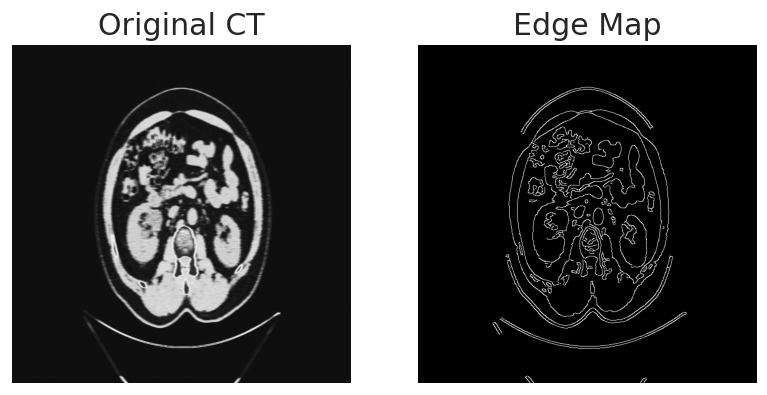

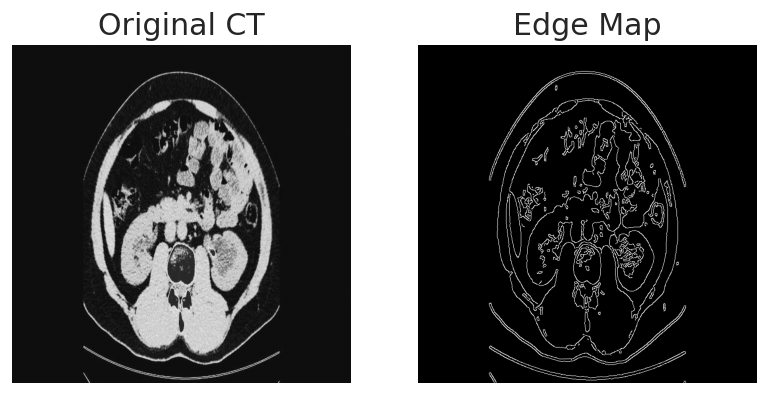

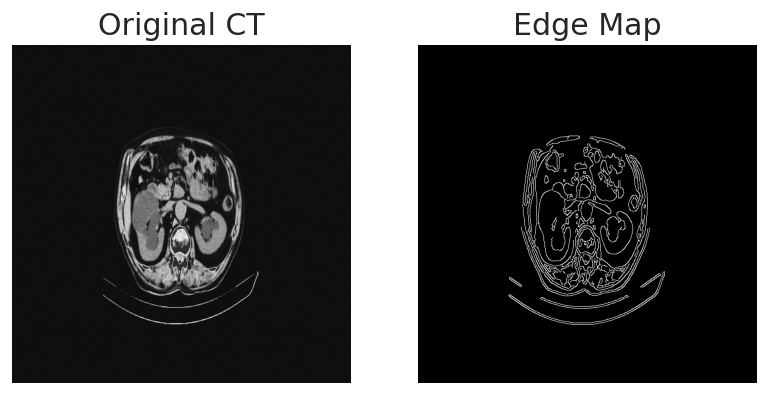

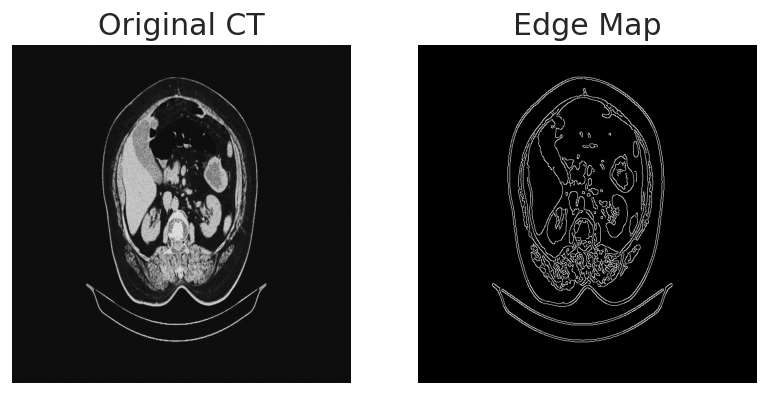

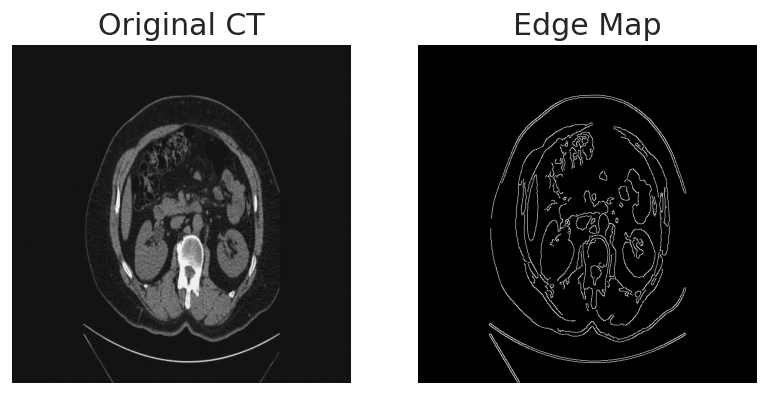

In [ ]:
import matplotlib.pyplot as plt
import random
import os

# Function to load and generate pairs from a folder
def generate_pairs(folder, num_samples=5):
    # Get all images recursively
    exts = ["*.jpg", "*.png", "*.jpeg"]
    images = []
    for ext in exts:
        images.extend(glob(os.path.join(folder, "**", ext), recursive=True))

    # Random sample to visualize
    sample_images = random.sample(images, min(num_samples, len(images)))

    for img_file in sample_images:
        img = cv2.imread(img_file, cv2.IMREAD_GRAYSCALE)
        edge = canny_edge(img)

        # Visualization side-by-side
        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1)
        plt.imshow(img, cmap='gray')
        plt.title("Original CT")
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.imshow(edge, cmap='gray')
        plt.title("Edge Map")
        plt.axis('off')

        plt.show()

# Test on 5 random train images
generate_pairs(train_path, num_samples=5)

## Step 4.3: Data Augmentation

- Augmentation increases dataset diversity without collecting new images.
- We apply **simple transforms** that preserve anatomical correctness:
  - **Horizontal flip** – mirror image left-right
  - **Vertical flip** – mirror image up-down
  - **Rotation** – small rotations (±15°) to simulate patient positioning variations
- These transforms help the AI generalize better and reduce overfitting.

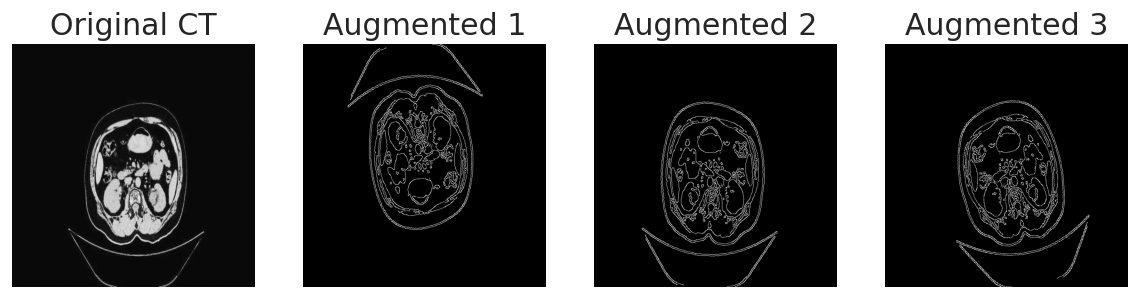

In [ ]:
import torchvision.transforms as T
from PIL import Image

# Define a simple augmentation pipeline
augmentation_transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15)
])

# Function to apply augmentation and visualize
def visualize_augmented(img_path, num_aug=3):
    img = Image.open(img_path).convert("L")  # Convert to grayscale PIL image
    edge = Image.fromarray(canny_edge(np.array(img)))  # Edge map as PIL

    plt.figure(figsize=(12,4))
    plt.subplot(1, num_aug+1, 1)
    plt.imshow(np.array(img), cmap='gray')
    plt.title("Original CT")
    plt.axis('off')

    for i in range(num_aug):
        img_aug = augmentation_transforms(img)
        edge_aug = augmentation_transforms(edge)
        plt.subplot(1, num_aug+1, i+2)
        plt.imshow(np.array(edge_aug), cmap='gray')
        plt.title(f"Augmented {i+1}")
        plt.axis('off')

    plt.show()

# Test on a random train image
random_train_img = random.choice(train_images)
visualize_augmented(random_train_img)

## Step 4.4: Define PyTorch Dataset & DataLoader

- We create a **custom PyTorch Dataset class** to load paired images:
  - **Input:** Edge Map (simulating low-bandwidth transmission)
  - **Target:** Original CT image
- The Dataset:
  - Reads images recursively from a folder
  - Applies **optional augmentation**
  - Converts images to PyTorch **tensors** normalized between 0 and 1
- The DataLoader:
  - Feeds data in **batches** (e.g., 16 images per batch)
  - Shuffles the dataset for training
  - Enables efficient GPU processing

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

# Custom Dataset for Edge → CT pairs
class KidneyCTDataset(Dataset):
    def __init__(self, root_folder, transform=None, augmentation=None):
        """
        root_folder: path to train/validation/test folder
        transform: basic transforms (to tensor, normalization)
        augmentation: optional data augmentation
        """
        self.images = []
        exts = ["*.jpg", "*.png", "*.jpeg"]
        for ext in exts:
            self.images.extend(glob(os.path.join(root_folder, "**", ext), recursive=True))
        self.transform = transform
        self.augmentation = augmentation

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("L")  # Original CT grayscale
        edge = Image.fromarray(canny_edge(np.array(img)))  # Generate edge map

        # Apply augmentation if provided
        if self.augmentation:
            img = self.augmentation(img)
            edge = self.augmentation(edge)

        # Apply transforms (to tensor, normalization)
        if self.transform:
            img = self.transform(img)
            edge = self.transform(edge)

        return edge, img  # input → target

# Define transforms: convert to tensor and normalize [0,1]
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

# Batch size
batch_size = 16

# Create Dataset and DataLoader for train, validation, test
train_dataset = KidneyCTDataset(train_path, transform=basic_transform, augmentation=augmentation_transforms)
validation_dataset = KidneyCTDataset(validation_path, transform=basic_transform)
test_dataset = KidneyCTDataset(test_path, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Test one batch
edges, targets = next(iter(train_loader))
print(f"Edges batch shape: {edges.shape}, Targets batch shape: {targets.shape}")

Edges batch shape: torch.Size([16, 1, 640, 640]), Targets batch shape: torch.Size([16, 1, 640, 640])


## Step 5: Define Generator (U-Net)

- The **Generator** is a **U-Net architecture**, widely used for image-to-image translation tasks.
- It consists of:
  - **Encoder (Downsampling)**: captures context from the edge map.
  - **Decoder (Upsampling)**: reconstructs the original CT from learned features.
  - **Skip connections**: help preserve spatial details from input.
- Input: Edge map (1 channel)
- Output: Reconstructed CT (1 channel)
- Losses will later ensure that the reconstructed kidney stone aligns with the original.

In [ ]:
import torch
import torch.nn as nn

# Define a double conv block
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

# Define U-Net Generator
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64,128,256,512]):
        super(UNetGenerator, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Decoder
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)  # upconv
            skip_connection = skip_connections[idx//2]

            # if size mismatch due to pooling
            if x.shape != skip_connection.shape:
                x = nn.functional.interpolate(x, size=skip_connection.shape[2:])

            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](x)  # double conv

        return self.final_conv(x)

# Test U-Net Generator
device = "cuda" if torch.cuda.is_available() else "cpu"
gen = UNetGenerator().to(device)

sample_input = torch.randn(1, 1, 640, 640).to(device)
sample_output = gen(sample_input)
print(f"Input shape: {sample_input.shape}, Output shape: {sample_output.shape}")

Input shape: torch.Size([1, 1, 640, 640]), Output shape: torch.Size([1, 1, 640, 640])


## Step 6: Define Discriminator (PatchGAN)

- **PatchGAN** looks at **N×N patches** instead of the whole image, improving high-frequency detail detection.
- Input: Concatenated pair of **Edge Map + Target/Generated CT** (2 channels)
- Output: Patch-level realism score
- This discriminator will guide the Generator to produce **more realistic reconstructions**.

In [ ]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=2, features=[64,128,256,512]):
        """
        in_channels: typically 2 (Edge map + CT)
        features: number of filters per layer
        """
        super(PatchGANDiscriminator, self).__init__()
        layers = []

        for feature in features:
            layers.append(
                nn.Conv2d(in_channels, feature, kernel_size=4, stride=2, padding=1)
            )
            layers.append(nn.BatchNorm2d(feature))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            in_channels = feature

        # Final output layer: 1 channel
        layers.append(nn.Conv2d(features[-1], 1, kernel_size=4, padding=1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Test Discriminator
disc = PatchGANDiscriminator().to(device)

# Sample input: concatenate edge + target
sample_disc_input = torch.cat((sample_input, sample_output), dim=1)  # 2 channels
sample_disc_output = disc(sample_disc_input)
print(f"Discriminator input shape: {sample_disc_input.shape}, output shape: {sample_disc_output.shape}")

Discriminator input shape: torch.Size([1, 2, 640, 640]), output shape: torch.Size([1, 1, 39, 39])


## Step 7: Initialize Weights

- Proper weight initialization is crucial for GAN training stability.
- We use **Xavier/normal initialization** for all convolutional layers and **zeros for biases**.
- Both the Generator and Discriminator are initialized using the same function.
- This ensures the networks start training from a balanced state.

In [ ]:
def initialize_weights(model):
    """
    Initialize Conv and BatchNorm layers in a model.
    Conv: Normal(mean=0, std=0.02)
    BatchNorm: weight=1, bias=0
    """
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias.data, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight.data, 1.0)
            nn.init.constant_(m.bias.data, 0.0)

# Apply initialization
initialize_weights(gen)
initialize_weights(disc)

# Verify first conv layer weights
print("Generator first conv layer weight mean:", gen.downs[0].double_conv[0].weight.mean().item())
print("Discriminator first conv layer weight mean:", disc.model[0].weight.mean().item())

Generator first conv layer weight mean: 0.0015349547611549497
Discriminator first conv layer weight mean: -0.0003837204712908715


## Step 8: Loss Functions & Optimizers

- **Adversarial Loss (BCEWithLogitsLoss)**: measures whether the Generator can fool the Discriminator.
- **L1 Loss**: ensures reconstructed CT matches the original CT at the pixel level (important for preserving kidney stones).
- **Optimizers**: Adam optimizer is commonly used in GANs for both Generator and Discriminator.
- Learning rate = 0.0002, Beta1 = 0.5, Beta2 = 0.999 (typical for GANs).

In [ ]:
# Loss functions
bce_loss = nn.BCEWithLogitsLoss()  # adversarial loss
l1_loss = nn.L1Loss()             # pixel-wise reconstruction loss

# Optimizers
lr = 2e-4
beta1 = 0.5
beta2 = 0.999

gen_optimizer = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta1, beta2))
disc_optimizer = torch.optim.Adam(disc.parameters(), lr=lr, betas=(beta1, beta2))

print("Loss functions and optimizers ready.")

Loss functions and optimizers ready.


## Step 9: Channel Noise Simulation

- In real rural networks, transmitted images may lose some pixels (“packet loss”).
- We simulate this by randomly dropping a small percentage of pixels in the **edge map**.
- This helps the Generator learn **robust reconstruction** even with incomplete input.
- Parameter: `noise_level` controls the percentage of pixels randomly set to 0.

In [ ]:
def add_channel_noise(edge_tensor, noise_level=0.05):
    """
    Randomly zero out a fraction of pixels in the edge map.

    Parameters:
    - edge_tensor: PyTorch tensor [B, 1, H, W]
    - noise_level: fraction of pixels to drop (e.g., 0.05 = 5%)

    Returns:
    - noisy_edge: tensor with random pixels zeroed
    """
    noisy_edge = edge_tensor.clone()
    B, C, H, W = noisy_edge.shape
    num_pixels = int(H * W * noise_level)

    for b in range(B):
        for c in range(C):
            idx = torch.randint(0, H*W, (num_pixels,))
            noisy_edge[b, c].view(-1)[idx] = 0.0
    return noisy_edge

# Test function
sample_noisy_edge = add_channel_noise(edges, noise_level=0.1)
print("Original edge min/max:", edges.min().item(), edges.max().item())
print("Noisy edge min/max:", sample_noisy_edge.min().item(), sample_noisy_edge.max().item())

Original edge min/max: 0.0 1.0
Noisy edge min/max: 0.0 1.0


## Step 9 (Improved): Channel Noise Simulation with Visualization

- To simulate packet loss in low-bandwidth transmission, we randomly remove pixels in the edge map.
- This version:
  - Uses a **probabilistic mask** for faster and more efficient noise.
  - Includes **visualization**: shows original vs noisy edge maps side-by-side.
  - Makes it easy to tune `noise_level`.

In [ ]:
# Improved channel-noise utility + visualization
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Literal, Tuple

def add_channel_noise(
    edge_tensor: torch.Tensor,
    noise_level: float = 0.05,
    mode: Literal['pixel','block','salt_pepper','gaussian'] = 'pixel',
    block_size: int = 16,
    salt_pepper_ratio: float = 0.5,
    gaussian_std: float = 0.05,
    seed: Optional[int] = None,
) -> torch.Tensor:
    """
    Add different types of noise to an edge batch tensor [B, C, H, W].

    Parameters
    ----------
    edge_tensor:
        Input tensor in shape [B, C, H, W], values expected in [0,1] (float).
    noise_level:
        Fraction of pixels to corrupt (0.0 - 1.0).
    mode:
        'pixel'        -> random pixel dropout (vectorized Bernoulli mask)
        'block'        -> random block dropout (simulates packet loss)
        'salt_pepper'  -> random pixels set to 0 or 1
        'gaussian'     -> additive gaussian noise clipped to [0,1]
    block_size:
        Size of blocks for 'block' mode.
    salt_pepper_ratio:
        For salt_pepper: fraction of corrupted pixels that become 'salt' (1.0).
    gaussian_std:
        Standard deviation for gaussian noise (applied relative to value range).
    seed:
        Optional random seed for reproducibility.

    Returns
    -------
    noisy_edge:
        Tensor same shape & device as input with noise applied.
    """
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    if not torch.is_tensor(edge_tensor):
        raise TypeError("edge_tensor must be a torch.Tensor")

    # Keep device & dtype
    device = edge_tensor.device
    dtype = edge_tensor.dtype

    # Ensure float in [0,1]
    x = edge_tensor.float().to(device)
    B, C, H, W = x.shape

    # Pixel dropout / bernoulli mask (vectorized)
    if mode == 'pixel':
        # mask: 1 = keep, 0 = drop
        keep_prob = 1.0 - float(noise_level)
        mask = (torch.rand((B, C, H, W), device=device) < keep_prob).to(dtype)
        noisy = x * mask

    elif mode == 'salt_pepper':
        rand = torch.rand((B, C, H, W), device=device)
        noisy = x.clone()
        cp = noise_level * salt_pepper_ratio  # salt fraction
        dp = noise_level * (1.0 - salt_pepper_ratio)  # pepper fraction
        # salt
        noisy[rand < cp] = 1.0
        # pepper
        noisy[(rand >= cp) & (rand < cp + dp)] = 0.0

    elif mode == 'gaussian':
        noise = torch.randn((B, C, H, W), device=device) * float(gaussian_std)
        noisy = (x + noise).clamp(0.0, 1.0)

    elif mode == 'block':
        # Start with keep mask of ones
        mask = torch.ones((B, C, H, W), device=device, dtype=dtype)
        # Approximate number of blocks per image needed to reach noise_level
        block_area = block_size * block_size
        target_pixels = H * W * noise_level
        # Number of blocks (at least 1 if noise_level>0)
        n_blocks = max(1, int(np.round(target_pixels / block_area))) if noise_level > 0 else 0

        for b in range(B):
            for _ in range(n_blocks):
                top = np.random.randint(0, max(1, H - block_size + 1))
                left = np.random.randint(0, max(1, W - block_size + 1))
                mask[b, :, top:top+block_size, left:left+block_size] = 0.0
        noisy = x * mask

    else:
        raise ValueError(f"Unsupported mode: {mode}")

    return noisy.type(dtype)


def visualize_noisy_edges(
    edges: torch.Tensor,
    noisy_edges: torch.Tensor,
    targets: Optional[torch.Tensor] = None,
    n_examples: int = 4,
    figsize: Tuple[int,int] = (14, 4),
    save_path: Optional[str] = None
):
    """
    Nicely visualize original edge, noisy edge, overlay, and optional target.
    Shows up to n_examples from the batch.
    """
    # move to cpu and convert to numpy
    edges_np = edges.detach().cpu().numpy()
    noisy_np = noisy_edges.detach().cpu().numpy()
    if targets is not None:
        targets_np = targets.detach().cpu().numpy()
    else:
        targets_np = None

    B = edges_np.shape[0]
    n = min(n_examples, B)
    cols = 4 if targets_np is not None else 3

    plt.figure(figsize=(figsize[0], figsize[1] * n))
    for i in range(n):
        orig = edges_np[i, 0]
        noisy = noisy_np[i, 0]
        if targets_np is not None:
            tgt = targets_np[i, 0]
        # Original
        ax = plt.subplot(n, cols, i*cols + 1)
        ax.imshow(orig, cmap='gray', vmin=0, vmax=1)
        ax.set_title("Original Edge")
        ax.axis('off')
        # Noisy
        ax = plt.subplot(n, cols, i*cols + 2)
        ax.imshow(noisy, cmap='gray', vmin=0, vmax=1)
        ax.set_title("Noisy Edge")
        ax.axis('off')
        # Overlay (orig in red, noisy in gray) - create colored overlay
        ax = plt.subplot(n, cols, i*cols + 3)
        # build RGB image for overlay
        overlay = np.stack([orig, orig, orig], axis=-1)
        # highlight where noisy has zeros or differences
        diff = np.abs(orig - noisy)
        # put diffs in red channel for visibility
        overlay[..., 0] = np.clip(overlay[..., 0] + diff, 0, 1)
        overlay[..., 1] = overlay[..., 1] * (1 - diff*0.5)
        overlay[..., 2] = overlay[..., 2] * (1 - diff*0.5)
        ax.imshow(overlay)
        ax.set_title("Overlay (red = changed)")
        ax.axis('off')

        if targets_np is not None:
            ax = plt.subplot(n, cols, i*cols + 4)
            ax.imshow(tgt, cmap='gray', vmin=0, vmax=1)
            ax.set_title("Target CT")
            ax.axis('off')

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# -------------------------
# Example usage (run in Colab after you have `edges, targets` from the DataLoader)
# -------------------------
edges, targets = next(iter(train_loader))   # example; edges in shape [B,1,H,W], values 0..1
device = edges.device

# 1) Pixel dropout (fast, vectorized)
noisy_pixel = add_channel_noise(edges, noise_level=0.1, mode='pixel', seed=42)
visualize_noisy_edges(edges, noisy_pixel, targets, n_examples=4)

# 2) Block dropout (simulates packet/block loss)
noisy_block = add_channel_noise(edges, noise_level=0.1, mode='block', block_size=24, seed=42)
visualize_noisy_edges(edges, noisy_block, targets, n_examples=4)

# 3) Salt & pepper
noisy_sp = add_channel_noise(edges, noise_level=0.08, mode='salt_pepper', salt_pepper_ratio=0.6, seed=42)
visualize_noisy_edges(edges, noisy_sp, targets, n_examples=4)

# 4) Gaussian noise
noisy_gauss = add_channel_noise(edges, noise_level=0.0, mode='gaussian', gaussian_std=0.03, seed=42)
visualize_noisy_edges(edges, noisy_gauss, targets, n_examples=4)

Output hidden; open in https://colab.research.google.com to view.

Compute percentage of changed pixels per sample (useful for logging / analysis).

Integrate multiple noise modes randomly per batch (makes training more robust).

Produce a small summary figure showing multiple noise types side-by-side

In [ ]:
# New cell: Professional Noise Visualization + Analysis
import matplotlib.patches as patches
import random # Needed for random.choice

# Re-defining these functions to be accessible in this scope and use the general add_channel_noise
def compute_changed_percentage(orig_tensor, noisy_tensor):
    # Ensure tensors are on CPU for comparison if they're on different devices
    orig_cpu = orig_tensor.detach().cpu()
    noisy_cpu = noisy_tensor.detach().cpu()
    changed = (orig_cpu != noisy_cpu).float()
    B = orig_cpu.shape[0]
    total = changed.view(B, -1).size(1)
    perc = changed.view(B, -1).sum(dim=1) / float(total) * 100.0
    return perc

def apply_random_noise_batch(edges_tensor, noise_level=0.05, modes=None):
    if modes is None:
        modes = ['pixel','block','salt_pepper','gaussian']
    mode = random.choice(modes)
    # Use the general add_channel_noise defined earlier (cell 8oM6DflV0sf8)
    noisy = add_channel_noise(edges_tensor, noise_level=noise_level, mode=mode, seed=random.randint(0,9999))
    return noisy, mode

def visualize_noise_summary_professional(
    edges: torch.Tensor,
    targets: torch.Tensor,
    noise_modes: list = ['pixel','block','salt_pepper','gaussian'],
    noise_level: float = 0.1,
    sample_count: int = 3
):
    """
    Professional visualization for SOP/paper:
    Shows Original Edge, Target CT, multiple noise modes, and highlights differences.
    """
    edges_np = edges.detach().cpu().numpy()
    targets_np = targets.detach().cpu().numpy()

    n_modes = len(noise_modes)
    cols = n_modes + 2  # Original + Target + noise modes
    plt.figure(figsize=(5*cols, 5*sample_count))

    for s in range(min(sample_count, edges.shape[0])):
        orig = edges_np[s,0]
        tgt = targets_np[s,0]

        # Original Edge
        ax = plt.subplot(sample_count, cols, s*cols + 1)
        ax.imshow(orig, cmap='gray', vmin=0, vmax=1)
        ax.set_title("Original Edge", fontsize=12, fontweight='bold', color='navy')
        ax.axis('off')
        # Draw border
        for spine in ax.spines.values():
            spine.set_edgecolor('navy')
            spine.set_linewidth(2)

        # Target CT
        ax = plt.subplot(sample_count, cols, s*cols + 2)
        ax.imshow(tgt, cmap='gray', vmin=0, vmax=1)
        ax.set_title("Target CT", fontsize=12, fontweight='bold', color='green')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor('green')
            spine.set_linewidth(2)

        # Apply each noise mode
        for i, mode in enumerate(noise_modes):
            # The add_channel_noise function from cell 8oM6DflV0sf8 is used here
            noisy = add_channel_noise(edges[s:s+1], noise_level=noise_level, mode=mode)
            noisy_np = noisy[0,0].cpu().numpy()

            # Display noisy edge
            ax = plt.subplot(sample_count, cols, s*cols + i+3)
            ax.imshow(noisy_np, cmap='gray', vmin=0, vmax=1)
            ax.set_title(mode.replace("_"," ").title(), fontsize=12, fontweight='bold', color='darkred')
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor('darkred')
                spine.set_linewidth(2)

            # Overlay heatmap of changed pixels
            diff = np.abs(orig - noisy_np)
            ax.imshow(diff, cmap='Reds', alpha=0.3)

    plt.tight_layout()
    plt.show()

# -----------------------------
# Example usage with your batch
# -----------------------------
# Assuming train_loader is defined and accessible
edges, targets = next(iter(train_loader))  # get one batch

# Apply random noise per batch and log mode
noisy_edges, mode_applied = apply_random_noise_batch(edges, noise_level=0.1)
print(f"Random noise mode applied to this batch: {mode_applied}")

# Compute % of changed pixels
perc_changed = compute_changed_percentage(edges, noisy_edges)
print("Percentage of changed pixels per sample in batch:")
print(perc_changed)

# Visualize summary in professional style
visualize_noise_summary_professional(edges, targets, noise_level=0.1, sample_count=3)


Output hidden; open in https://colab.research.google.com to view.

## Step 10: Training Loop (Generator + Discriminator)

- Each iteration (batch) does the following:
    1. Apply random noise to the input edge maps (simulates low-bandwidth).
    2. Generator reconstructs CT from noisy edges.
    3. Discriminator evaluates both real (Target CT) and fake (Generated CT) images.
    4. Compute losses:
        - Generator: adversarial (BCE) + pixel-wise L1 loss.
        - Discriminator: adversarial loss on real/fake.
    5. Backpropagation and optimizer steps.
- Every few epochs, save:
    - Sample reconstructed images for visualization.
    - Checkpoints of Generator & Discriminator (.pth) to Google Drive.
- Mixed-noise per batch ensures robustness.
- Logs % of changed pixels, losses, and visual comparisons.

In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

AttributeError: module 'torch._C' has no attribute '_cuda_resetPeakMemoryStats'

Dataset sizes: 2000 400 400
Using device: cuda
Starting training (minimal, stable).
Epoch 1/5  |  Gen Loss: 11.8623  |  Disc Loss: 0.5690  |  last noise: gaussian  |  last %changed: 50.02%


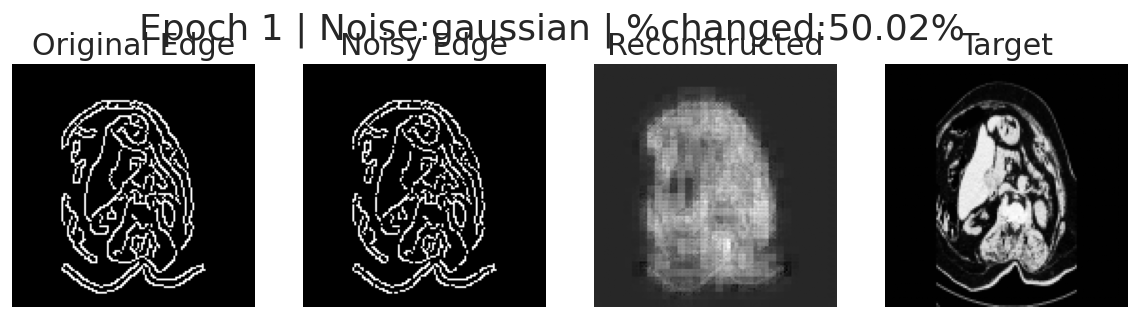

Epoch 2/5  |  Gen Loss: 11.4029  |  Disc Loss: 0.5355  |  last noise: gaussian  |  last %changed: 50.62%


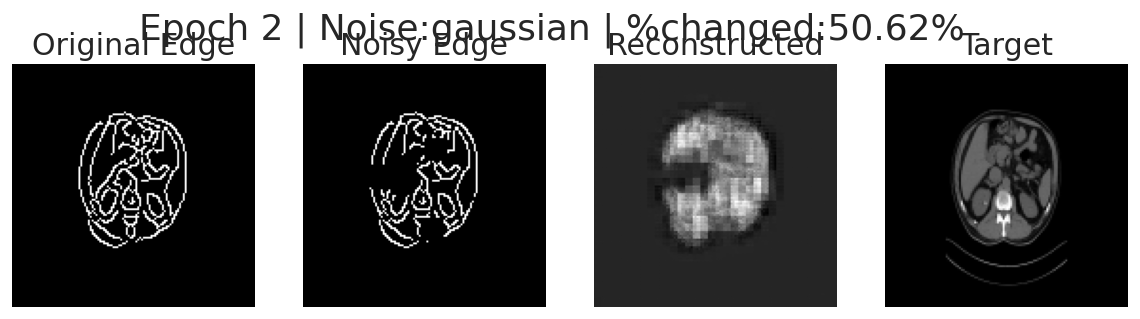

Epoch 3/5  |  Gen Loss: 11.4307  |  Disc Loss: 0.5190  |  last noise: salt_pepper  |  last %changed: 4.69%


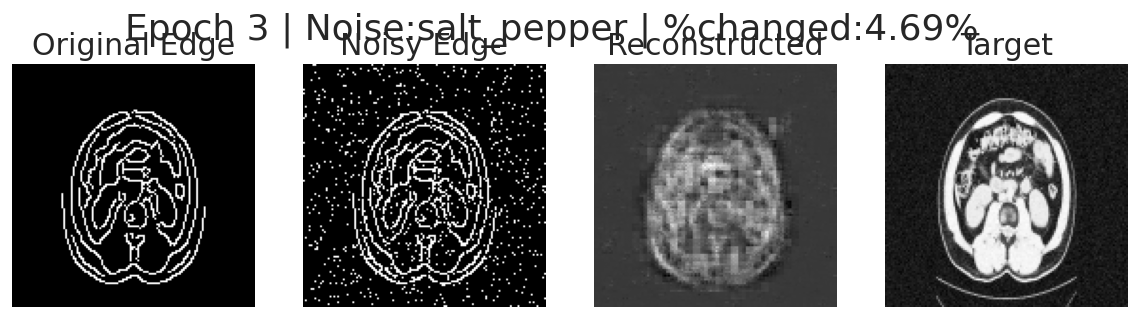

Epoch 4/5  |  Gen Loss: 11.2663  |  Disc Loss: 0.5397  |  last noise: gaussian  |  last %changed: 50.16%


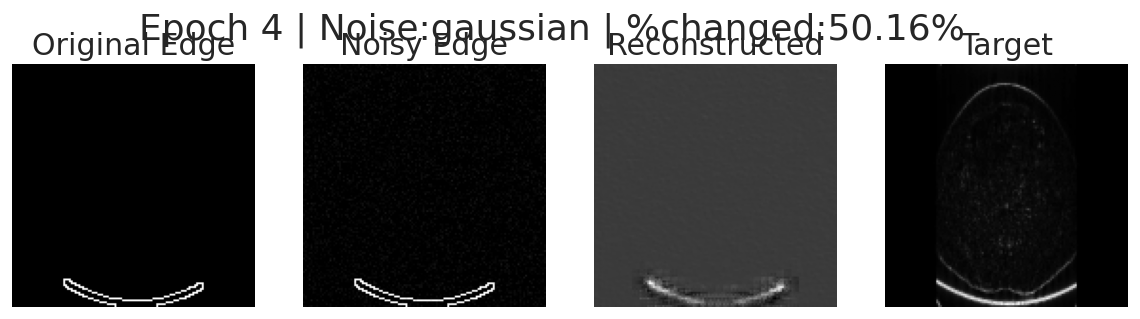

Epoch 5/5  |  Gen Loss: 11.1180  |  Disc Loss: 0.5484  |  last noise: block  |  last %changed: 0.92%


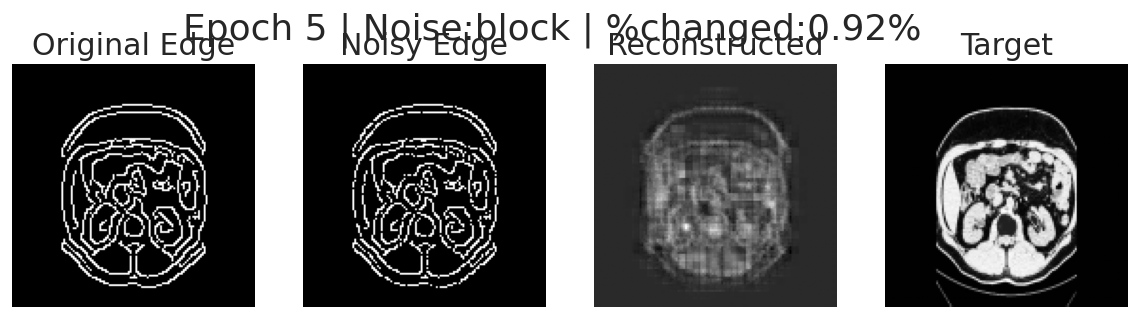

Training complete (minimal).


In [ ]:
# Fixed minimal Colab-safe training cell (no indentation errors)
import os
import random
import gc
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---------- CONFIG ----------
dataset_base = "/content/drive/MyDrive/Colab Notebooks/Kidney_Semantic_Project/dataset"
train_path = os.path.join(dataset_base, "train")
validation_path = os.path.join(dataset_base, "validation")
test_path = os.path.join(dataset_base, "test")

image_size = 128
batch_size = 1
num_epochs = 5
noise_level = 0.10
visualize_every = 1
seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# clear memory
torch.cuda.empty_cache()
gc.collect()

# ---------- lightweight canny ----------
def canny_edge(img_np, low=50, high=150):
    if img_np.ndim == 3:
        img_gray = cv2.cvtColor(img_np, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img_np
    blurred = cv2.GaussianBlur(img_gray, (5,5), 1.4)
    edges = cv2.Canny(blurred, low, high)
    return (edges > 0).astype(np.float32)

# ---------- Dataset ----------
class TinyKidneyDataset(Dataset):
    def __init__(self, root_folder, image_size=128):
        exts = ["*.jpg","*.png","*.jpeg"]
        paths = []
        for e in exts:
            paths += glob(os.path.join(root_folder, "**", e), recursive=True)
        self.paths = sorted(paths)
        self.image_size = image_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise RuntimeError(f"Cannot read image: {p}")
        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0
        edge = canny_edge((img * 255).astype(np.uint8))
        img_t = torch.from_numpy(img).unsqueeze(0).float()
        edge_t = torch.from_numpy(edge).unsqueeze(0).float()
        return edge_t, img_t

# ---------- CPU noise helpers ----------
def add_channel_noise_cpu(edge_cpu, noise_level=0.05, mode='pixel', block_size=12, salt_ratio=0.5, gaussian_std=0.03, seed=None):
    if seed is not None:
        torch.manual_seed(seed); np.random.seed(seed)
    if edge_cpu.device.type != 'cpu':
        edge_cpu = edge_cpu.detach().cpu()
    x = edge_cpu.clone()
    B,C,H,W = x.shape

    if mode == 'pixel':
        keep = 1.0 - float(noise_level)
        mask = (torch.rand((B,C,H,W)) < keep).float()
        noisy = x * mask

    elif mode == 'salt_pepper':
        noisy = x.clone()
        r = torch.rand((B,C,H,W))
        salt_p = noise_level * salt_ratio
        pepper_p = noise_level * (1 - salt_ratio)
        noisy[r < salt_p] = 1.0
        noisy[(r >= salt_p) & (r < salt_p + pepper_p)] = 0.0

    elif mode == 'gaussian':
        noise = torch.randn((B,C,H,W)) * float(gaussian_std)
        noisy = (x + noise).clamp(0.0, 1.0)

    elif mode == 'block':
        noisy = x.clone()
        block_area = block_size * block_size
        total_pixels = H * W
        target_pixels = int(total_pixels * noise_level)
        n_blocks = max(1, int(np.round(target_pixels / block_area))) if noise_level > 0 else 0
        for b in range(B):
            for _ in range(n_blocks):
                top = np.random.randint(0, max(1, H - block_size + 1))
                left = np.random.randint(0, max(1, W - block_size + 1))
                noisy[b, :, top:top+block_size, left:left+block_size] = 0.0
    else:
        raise ValueError("Unsupported mode")
    return noisy

def compute_changed_percentage_cpu(orig_cpu, noisy_cpu):
    changed = (orig_cpu != noisy_cpu).float()
    B = orig_cpu.shape[0]
    total = changed.view(B, -1).size(1)
    perc = changed.view(B, -1).sum(dim=1) / float(total) * 100.0
    return perc

def apply_random_noise_batch_cpu(edges_cpu, noise_level=0.05, modes=None):
    if modes is None:
        modes = ['pixel','block','salt_pepper','gaussian']
    mode = random.choice(modes)
    noisy = add_channel_noise_cpu(edges_cpu, noise_level=noise_level, mode=mode, seed=random.randint(0,9999))
    return noisy, mode

# ---------- tiny models ----------
class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(inplace=True))
        self.conv2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True))
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.final = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        d1 = self.conv1(x)
        d2 = self.conv2(self.pool(d1))
        b = self.bottleneck(self.pool(d2))
        u1 = self.up1(b) + d2
        u2 = self.up2(u1) + d1
        return self.final(u2)

class TinyPatchGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 16, 4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(16, 32, 4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 1, 4, padding=1)
        )

    def forward(self, x):
        return self.net(x)

# ---------- prepare data & models ----------
train_ds = TinyKidneyDataset(train_path, image_size=image_size)
val_ds = TinyKidneyDataset(validation_path, image_size=image_size)
test_ds = TinyKidneyDataset(test_path, image_size=image_size)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# clear, then create and move models
torch.cuda.empty_cache()
gc.collect()
gen = TinyUNet().to(device)
disc = TinyPatchGAN().to(device)

# ---------- losses & optimizers ----------
bce_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()
gen_opt = torch.optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
disc_opt = torch.optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))

# ---------- training loop ----------
print("Starting training (minimal, stable).")
for epoch in range(1, num_epochs + 1):
    gen.train()
    disc.train()
    epoch_g = 0.0
    epoch_d = 0.0
    last_mode = None
    last_perc = 0.0

    for batch_idx, (edges_cpu, targets_cpu) in enumerate(train_loader):
        # edges_cpu, targets_cpu on CPU
        noisy_cpu, mode = apply_random_noise_batch_cpu(edges_cpu, noise_level=noise_level)
        perc = compute_changed_percentage_cpu(edges_cpu, noisy_cpu)
        last_mode = mode
        last_perc = float(perc.mean().item())

        # Move minimal tensors to GPU
        edges = edges_cpu.to(device)
        targets = targets_cpu.to(device)

        # ---- Discriminator ----
        disc_opt.zero_grad()
        with torch.no_grad():
            noisy_dev = noisy_cpu.to(device)
            fake_for_disc = gen(noisy_dev)
        fake_input = torch.cat([edges, fake_for_disc.detach()], dim=1)
        real_input = torch.cat([edges, targets], dim=1)

        real_out = disc(real_input)
        fake_out = disc(fake_input)

        real_labels = torch.ones_like(real_out, device=device)
        fake_labels = torch.zeros_like(fake_out, device=device)

        d_loss = 0.5 * (bce_loss(real_out, real_labels) + bce_loss(fake_out, fake_labels))
        d_loss.backward()
        disc_opt.step()

        # ---- Generator ----
        gen_opt.zero_grad()
        noisy_dev = noisy_cpu.to(device)
        fake = gen(noisy_dev)  # gradients tracked here
        fake_input_for_g = torch.cat([edges, fake], dim=1)
        out_g = disc(fake_input_for_g)

        adv = bce_loss(out_g, torch.ones_like(out_g, device=device))
        pix = l1_loss(fake, targets)
        g_loss = adv + 100.0 * pix

        g_loss.backward()
        gen_opt.step()

        epoch_g += float(g_loss.item())
        epoch_d += float(d_loss.item())

        # cleanup to keep memory low
        del edges, targets, noisy_dev, fake_for_disc, fake_input, real_input, real_out, fake_out, fake, fake_input_for_g, out_g
        torch.cuda.empty_cache()
        gc.collect()

    avg_g = epoch_g / max(1, len(train_loader))
    avg_d = epoch_d / max(1, len(train_loader))
    print(f"Epoch {epoch}/{num_epochs}  |  Gen Loss: {avg_g:.4f}  |  Disc Loss: {avg_d:.4f}  |  last noise: {last_mode}  |  last %changed: {last_perc:.2f}%")

    # visualization
    if epoch % visualize_every == 0:
        gen.eval()
        edges_cpu_v, targets_cpu_v = next(iter(train_loader))
        noisy_cpu_v, _ = apply_random_noise_batch_cpu(edges_cpu_v, noise_level=noise_level)
        with torch.no_grad():
            edges_v = edges_cpu_v.to(device)
            noisy_v = noisy_cpu_v.to(device)
            fake_v = gen(noisy_v)
        a = edges_v[0,0].cpu().numpy()
        b = noisy_v[0,0].cpu().numpy()
        c = fake_v[0,0].cpu().numpy()
        d = targets_cpu_v[0,0].cpu().numpy()
        fig, ax = plt.subplots(1,4,figsize=(12,3))
        ax[0].imshow(a, cmap='gray'); ax[0].set_title('Original Edge'); ax[0].axis('off')
        ax[1].imshow(b, cmap='gray'); ax[1].set_title('Noisy Edge'); ax[1].axis('off')
        ax[2].imshow(c, cmap='gray'); ax[2].set_title('Reconstructed'); ax[2].axis('off')
        ax[3].imshow(d, cmap='gray'); ax[3].set_title('Target'); ax[3].axis('off')
        plt.suptitle(f"Epoch {epoch} | Noise:{last_mode} | %changed:{last_perc:.2f}%")
        plt.show()
        del edges_v, noisy_v, fake_v
        torch.cuda.empty_cache()
        gc.collect()

print("Training complete (minimal).")

# Evaluation & Results

In this section we quantify how well **SemanticEdge-Trans** reconstructs full CT scans from edge-only inputs (our simulated low-bandwidth transmission).  
We evaluate using pixel-level and perceptual metrics that matter for medical reconstruction tasks:

- **Mean Squared Error (MSE)** — simple pixel-wise distance; lower is better.
- **PSNR (Peak Signal-to-Noise Ratio)** — relates MSE to perceived image quality; higher is better.
- **SSIM (Structural Similarity Index)** — measures structural similarity; higher is better (computed if `scikit-image` is available).

Why these metrics matter:
- These metrics together describe fidelity (MSE), perceptual signal quality (PSNR), and structural preservation (SSIM) — three properties important when reconstructing medical images where small structural details (e.g., stones) matter.
- We also provide clear visualizations: distribution plots to see the variability across the test set and example reconstructions so a human reader can quickly judge clinical relevance.

Below we compute summary statistics, show result distributions, and present representative reconstructed examples for visual inspection. These figures and the summary table are suitable to include in a lab report or slide deck for examiners.

In [23]:
# Improved Evaluation + Publication-style Visualization
# Run this after training. Assumes: `gen`, `val_loader` (or validation loader),
# `apply_random_noise_batch_cpu` and `noise_level` and `device` exist from your notebook.

import os, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import torch
from skimage.metrics import structural_similarity as sk_ssim  # optional but best

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "font.size": 11,
    "figure.autolayout": True
})

# ----------------- metric helpers -----------------
def psnr_numpy(a: np.ndarray, b: np.ndarray) -> float:
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return float(100.0)
    return float(20.0 * np.log10(1.0 / np.sqrt(mse)))

def ssim_fast(a: np.ndarray, b: np.ndarray) -> float:
    # prefer skimage if available for more standard SSIM
    try:
        return float(sk_ssim(a, b, data_range=1.0))
    except Exception:
        # fallback (fast approximate, global)
        a = a.astype(np.float64); b = b.astype(np.float64)
        C1 = 0.01**2; C2 = 0.03**2
        mu_a = a.mean(); mu_b = b.mean()
        sigma_a = ((a - mu_a) ** 2).mean()
        sigma_b = ((b - mu_b) ** 2).mean()
        sigma_ab = ((a - mu_a) * (b - mu_b)).mean()
        denom = (mu_a**2 + mu_b**2 + C1) * (sigma_a + sigma_b + C2)
        if denom == 0: return 0.0
        return float(((2*mu_a*mu_b + C1) * (2*sigma_ab + C2)) / denom)

# ----------------- evaluation config -----------------
NUM_SAMPLES_TO_SHOW = 6   # how many sample rows to create (first N from validation)
SAVE_RESULTS_CSV = True
SAVE_SAMPLES_TO = "/content/drive/MyDrive/Colab Notebooks/Kidney_Semantic_Project/eval_samples"
os.makedirs(SAVE_SAMPLES_TO, exist_ok=True)

gen.eval()
results = []   # will hold per-sample metrics for table
psnr_list = []
ssim_list = []

print("Running polished evaluation on validation set... (this may take a little while)")

with torch.no_grad():
    for idx, (edges_cpu, targets_cpu) in enumerate(val_loader):
        # apply same noise style as training
        noisy_cpu, mode = apply_random_noise_batch_cpu(edges_cpu, noise_level=noise_level)

        # move only minimal tensors to device
        noisy = noisy_cpu.to(device)
        targets = targets_cpu.to(device)

        # generate output
        outputs = gen(noisy)

        # Bring arrays to CPU numpy
        out_np = outputs[0,0].cpu().numpy()
        tgt_np = targets[0,0].cpu().numpy()
        edge_np = edges_cpu[0,0].numpy()
        noisy_np = noisy_cpu[0,0].numpy()

        # compute metrics
        l1 = float(np.mean(np.abs(out_np - tgt_np)))
        psnr = psnr_numpy(out_np, tgt_np)
        ssim = ssim_fast(out_np, tgt_np)

        results.append({
            "index": idx,
            "noise_mode": mode,
            "l1": l1,
            "psnr": psnr,
            "ssim": ssim
        })
        psnr_list.append(psnr)
        ssim_list.append(ssim)

        # Optionally save sample images for (png)
        if idx < NUM_SAMPLES_TO_SHOW:
            # create high-quality sample figure (Edge | Noisy | Generated + heatmap | Target)
            fig, axes = plt.subplots(1, 4, figsize=(16,4), dpi=120)
            # common display params
            vmin, vmax = 0.0, 1.0

            # Original Edge
            ax = axes[0]
            ax.imshow(edge_np, cmap='gray', vmin=vmin, vmax=vmax)
            ax.set_title("Edge", fontsize=11, color="#0b5394")
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor("#0b5394"); spine.set_linewidth(2.0)

            # Noisy Edge
            ax = axes[1]
            ax.imshow(noisy_np, cmap='gray', vmin=vmin, vmax=vmax)
            ax.set_title(f"Noisy ({mode})", fontsize=11, color="#b45f06")
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor("#b45f06"); spine.set_linewidth(2.0)

            # Generated with Diff overlay
            ax = axes[2]
            ax.imshow(out_np, cmap='gray', vmin=vmin, vmax=vmax)
            # heatmap of absolute error
            diff = np.abs(out_np - tgt_np)
            # overlay heatmap (inferno) with alpha determined by normalized error
            heat = ax.imshow(diff, cmap='inferno', alpha=0.55, vmin=0, vmax=diff.max() if diff.max()>0 else 1e-6)
            ax.set_title("Generated + Error (overlay)", fontsize=11, color="#8e7cc3")
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor("#8e7cc3"); spine.set_linewidth(2.0)
            # colorbar for heatmap (small)
            cax = fig.add_axes([0.73, 0.12, 0.01, 0.25])  # [left, bottom, width, height]
            cb = fig.colorbar(heat, cax=cax)
            cb.ax.tick_params(labelsize=8)

            # Target
            ax = axes[3]
            ax.imshow(tgt_np, cmap='gray', vmin=vmin, vmax=vmax)
            ax.set_title("Ground Truth", fontsize=11, color="#38761d")
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor("#38761d"); spine.set_linewidth(2.0)

            # Metrics box under figure
            metrics_text = f"Idx: {idx}   |   L1: {l1:.4f}   |   PSNR: {psnr:.2f} dB   |   SSIM: {ssim:.3f}"
            plt.suptitle(metrics_text, fontsize=12, fontweight='bold')
            # save image file
            save_path = os.path.join(SAVE_SAMPLES_TO, f"eval_sample_{idx:03d}.png")
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            plt.show()
            plt.close(fig)

        # cleanup
        del noisy, outputs, targets
        torch.cuda.empty_cache()

# --- Summary table / dataframe
df = pd.DataFrame(results)
df_sorted = df.sort_values(by='psnr', ascending=False).reset_index(drop=True)

# Print summary statistics (clean and easy to copy)
print("\nEVALUATION SUMMARY (validation set)\n-----------------------------------")
print(f"Samples evaluated : {len(df)}")
print(f"Avg L1  : {df['l1'].mean():.6f}")
print(f"Avg PSNR : {df['psnr'].mean():.3f} dB  (std: {df['psnr'].std():.3f})")
print(f"Avg SSIM : {df['ssim'].mean():.4f}  (std: {df['ssim'].std():.4f})")
print("-----------------------------------\n")

# show top-5 and bottom-5 by PSNR for quick insight
print("Top 5 samples by PSNR:")
display(df_sorted.head(5)[['index','noise_mode','psnr','ssim','l1']])

print("\nBottom 5 samples by PSNR:")
display(df_sorted.tail(5)[['index','noise_mode','psnr','ssim','l1']])

# Save results CSV for your reproducibility
if SAVE_RESULTS_CSV:
    csv_path = os.path.join(SAVE_SAMPLES_TO, "evaluation_summary.csv")
    df.to_csv(csv_path, index=False)
    print(f"Saved per-sample CSV -> {csv_path}")

# Plot distributions (PSNR & SSIM)
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].hist(psnr_list, bins=30, color="#2b7bba", alpha=0.85)
ax[0].set_title("PSNR distribution (dB)")
ax[0].set_xlabel("PSNR (dB)")
ax[0].set_ylabel("Count")
ax[1].hist(ssim_list, bins=30, color="#6aa84f", alpha=0.85)
ax[1].set_title("SSIM distribution")
ax[1].set_xlabel("SSIM")
ax[1].set_ylabel("Count")
plt.show()

print("Done — evaluation visuals saved to:", SAVE_SAMPLES_TO)

Output hidden; open in https://colab.research.google.com to view.

### Thank you
### Project Made by Muhammad Imtiaz